In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/rfm_features.csv')

In [3]:
df.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,DistinctProducts,TenureDays,AvgItemsPerOrder
0,12346.0,326,2,0.00,0.000000,0,1,326,0.000000
1,12347.0,2,7,4310.00,23.681319,2458,103,367,351.142857
2,12348.0,75,4,1797.24,57.975484,2341,22,358,585.250000
3,12349.0,19,1,1757.55,24.076027,631,73,19,631.000000
4,12350.0,310,1,334.40,19.670588,197,17,310,197.000000


In [4]:
df["suspicious"] = (df["Monetary"] == 0) | (df["TotalItems"] == 0)

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [6]:
customer_ids = df["CustomerID"].values
suspicious_flags = df["suspicious"].values

features = df.drop(columns=["CustomerID", "suspicious"])

In [7]:
ss = StandardScaler()

X = ss.fit_transform(features).astype(np.float32)

In [8]:
X_train, X_val = train_test_split(X, test_size = 0.1, random_state = 42)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [10]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train)),
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val)),
    batch_size = 32
)

In [11]:
class AutoEncoder(nn.Module):
  def __init__(self, input_dim = 8, latent_dim = 2):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, latent_dim)
    )

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 8),
        nn.ReLU(),
        nn.Linear(8, 16),
        nn.ReLU(),
        nn.Linear(16, input_dim)
    )

  def forward(self, x):
    latent = self.encoder(x)
    reconstructed = self.decoder(latent)
    return reconstructed

  def encode(self, x):
    return self.encoder(x)

In [12]:
device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
model = AutoEncoder(input_dim = 8, latent_dim = 2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [13]:
def train(model, train_loader, val_loader, epochs = 200):
  train_losses, val_losses = [], []
  best_val_loss = float("inf")
  patience, patience_counter = 10, 0

  for epoch in range(epochs):
    model.train()
    batch_losses = []
    for (batch, ) in train_loader:
      batch = batch.to(device)
      optimizer.zero_grad()
      output = model(batch)
      loss = criterion(output, batch)
      loss.backward()
      optimizer.step()
      batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
      val_loss = np.mean([
          criterion(model(batch.to(device)), batch.to(device)).item()
          for (batch,) in val_loader
      ])
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      patience_counter = 0
      torch.save(model.state_dict(), "best_autoencoder.pt")
    else:
      patience_counter += 1
      if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
  model.load_state_dict(torch.load("best_autoencoder.pt"))
  return train_losses, val_losses

In [14]:
train_losses, val_losses = train(model, train_loader, val_loader)

Epoch  10 | Train Loss: 0.352712 | Val Loss: 0.262456
Epoch  20 | Train Loss: 0.268880 | Val Loss: 0.196467
Epoch  30 | Train Loss: 0.227479 | Val Loss: 0.181425
Epoch  40 | Train Loss: 0.182782 | Val Loss: 0.164529
Epoch  50 | Train Loss: 0.155769 | Val Loss: 0.134982
Epoch  60 | Train Loss: 0.171007 | Val Loss: 0.123463
Epoch  70 | Train Loss: 0.125081 | Val Loss: 0.145466
Epoch  80 | Train Loss: 0.110461 | Val Loss: 0.096606
Epoch  90 | Train Loss: 0.107350 | Val Loss: 0.096402
Epoch 100 | Train Loss: 0.107681 | Val Loss: 0.093370
Epoch 110 | Train Loss: 0.096823 | Val Loss: 0.092334
Epoch 120 | Train Loss: 0.095691 | Val Loss: 0.091705
Epoch 130 | Train Loss: 0.097991 | Val Loss: 0.088317
Epoch 140 | Train Loss: 0.092055 | Val Loss: 0.085249
Epoch 150 | Train Loss: 0.100364 | Val Loss: 0.085168
Epoch 160 | Train Loss: 0.088892 | Val Loss: 0.081311
Epoch 170 | Train Loss: 0.087217 | Val Loss: 0.080803
Epoch 180 | Train Loss: 0.085593 | Val Loss: 0.080090
Epoch 190 | Train Loss: 0.08

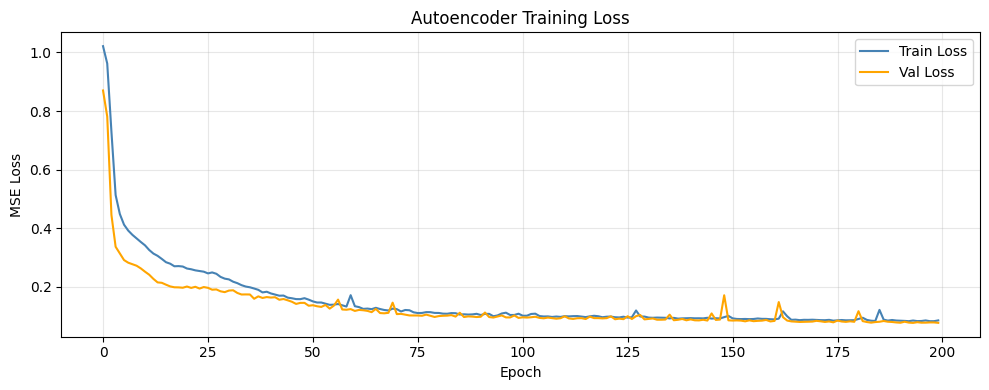

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="steelblue")
plt.plot(val_losses, label="Val Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

In [16]:
model.eval()
with torch.no_grad():
    X_encoded = model.encode(torch.tensor(X).to(device)).cpu().numpy()

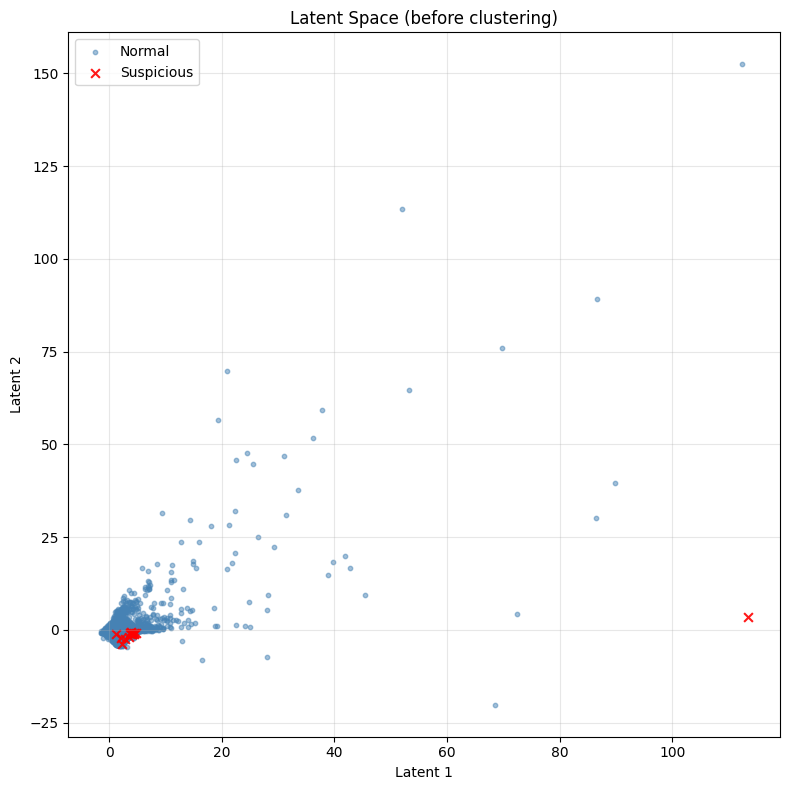

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(
    X_encoded[suspicious_flags == 0, 0],
    X_encoded[suspicious_flags == 0, 1],
    alpha=0.5, s=10, c="steelblue", label="Normal"
)
plt.scatter(
    X_encoded[suspicious_flags == 1, 0],
    X_encoded[suspicious_flags == 1, 1],
    alpha=0.9, s=40, c="red", marker="x", label="Suspicious"
)
plt.title("Latent Space (before clustering)")
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("latent_space.png", dpi=150)
plt.show()

In [ ]:
from scipy import stats

In [ ]:
z_scores = np.abs(stats.zscore(X_encoded))
extreme_mask = (z_scores > 3).any(axis=1)
print(f"Extreme outliers in latent space: {extreme_mask.sum()}")
print("Their CustomerIDs:")
print(customer_ids[extreme_mask])

In [20]:
X_core = X_encoded[~extreme_mask]
flags_core = suspicious_flags[~extreme_mask]

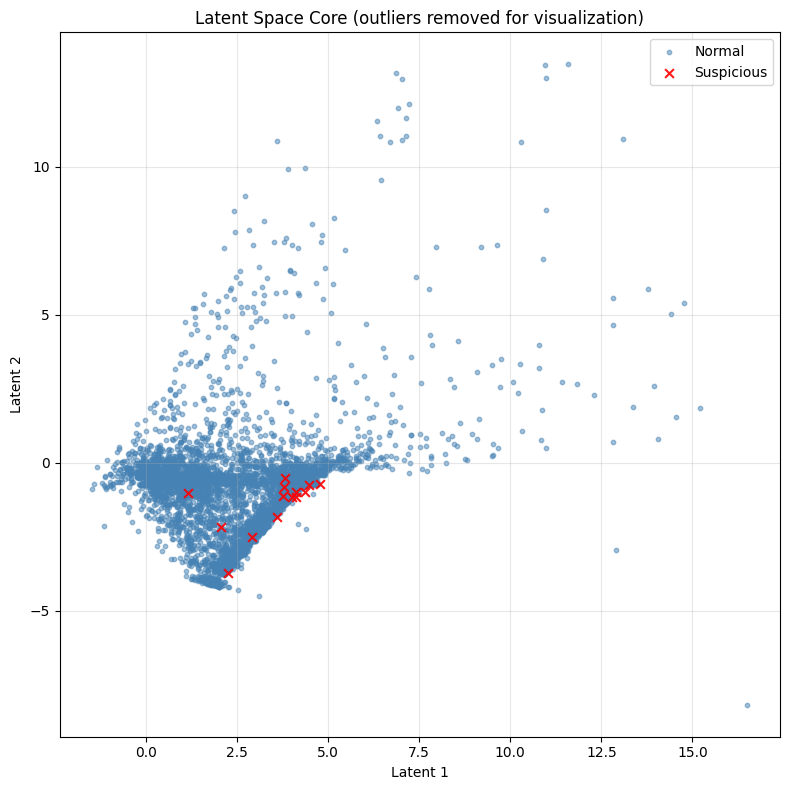

In [21]:
plt.figure(figsize=(8, 8))
plt.scatter(
    X_core[flags_core == 0, 0],
    X_core[flags_core == 0, 1],
    alpha=0.5, s=10, c="steelblue", label="Normal"
)
plt.scatter(
    X_core[flags_core == 1, 0],
    X_core[flags_core == 1, 1],
    alpha=0.9, s=40, c="red", marker="x", label="Suspicious"
)
plt.title("Latent Space Core (outliers removed for visualization)")
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("latent_space_core.png", dpi=150)
plt.show()

In [22]:
import hdbscan
import matplotlib.pyplot as plt
import numpy as np

In [23]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    cluster_selection_epsilon=0.5,
    metric="euclidean",
    cluster_selection_method="eom"
)

In [24]:
cluster_labels = clusterer.fit_predict(X_encoded)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()

In [25]:
print(f"Clusters found:    {n_clusters}")
print(f"Noise points:      {n_noise} ({n_noise/len(cluster_labels)*100:.1f}%)")
print(f"Cluster sizes:")
for label in sorted(set(cluster_labels)):
    if label == -1:
        print(f"  Noise:     {(cluster_labels == -1).sum()} customers")
    else:
        print(f"  Cluster {label}: {(cluster_labels == label).sum()} customers")


Clusters found:    2
Noise points:      846 (19.4%)
Cluster sizes:
  Noise:     846 customers
  Cluster 0: 37 customers
  Cluster 1: 3489 customers


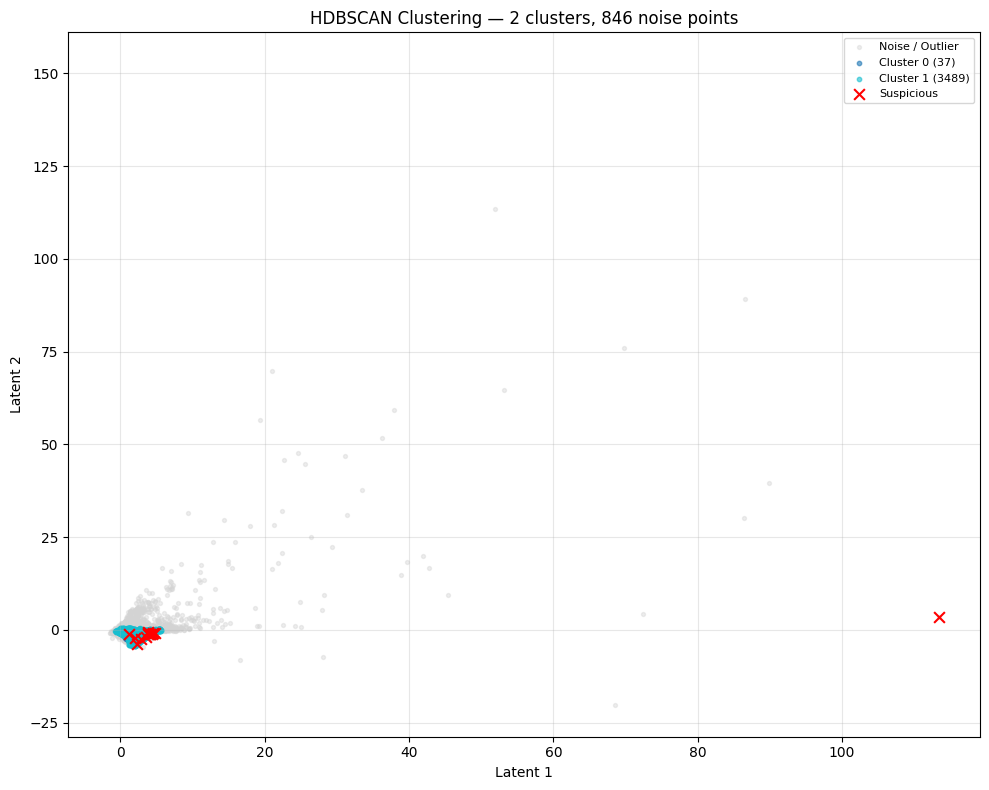

In [26]:
colors = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))

plt.figure(figsize=(10, 8))

for label in sorted(set(cluster_labels)):
    mask = cluster_labels == label
    if label == -1:
        plt.scatter(
            X_encoded[mask, 0], X_encoded[mask, 1],
            s=8, c="lightgray", alpha=0.4, label="Noise / Outlier"
        )
    else:
        plt.scatter(
            X_encoded[mask, 0], X_encoded[mask, 1],
            s=10, alpha=0.6, label=f"Cluster {label} ({mask.sum()})",
            color=colors[label]
        )

plt.scatter(
    X_encoded[suspicious_flags == 1, 0],
    X_encoded[suspicious_flags == 1, 1],
    s=60, c="red", marker="x", zorder=5, label="Suspicious"
)

plt.title(f"HDBSCAN Clustering — {n_clusters} clusters, {n_noise} noise points")
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.legend(loc="upper right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hdbscan_clusters.png", dpi=150)
plt.show()

In [27]:
df["cluster"] = cluster_labels
df["suspicious"] = suspicious_flags

print("\nCluster Profiles:")
profile_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue",
                "TotalItems", "DistinctProducts", "TenureDays", "AvgItemsPerOrder"]

cluster_profiles = df[df["cluster"] != -1].groupby("cluster")[profile_cols].mean().round(2)
print(cluster_profiles)


Cluster Profiles:
         Recency  Frequency  Monetary  AvgOrderValue  TotalItems  \
cluster                                                            
0         172.43       3.14    711.09          24.19      509.14   
1          98.29       3.46    856.70          22.11      492.33   

         DistinctProducts  TenureDays  AvgItemsPerOrder  
cluster                                                  
0                   36.89      349.49            171.32  
1                   43.61      216.37            146.00  
